# Ensembles of models

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/biprateep/lazy-tfm/blob/tutorials/ensembles.ipynb)
[![View on GitHub](https://img.shields.io/badge/View%20on-GitHub-181717?logo=github)](https://github.com/biprateep/lazy-tfm/blob/tutorials/ensembles.ipynb)

Different models make different errors, so the densities they predict for
the same row differ, and a combination of them can be better than any one of
them. In this tutorial, we pool the densities of TabPFN-3.5, LimiX-2 and
TabFM with `lazy.LazyEnsembleModel`, compare the three ways of pooling with
each model alone, and look at what the pools do to the densities of a few
rows. The page
[Ensembles of models](https://lazy-tfm.readthedocs.io/en/latest/guide/ensembles.html)
of the User guide describes the pools and our own tests of them.

## Setup

On Google Colab, the cell below installs the package with the three
backends we use. The code of LimiX is not on PyPI, so the `limix` extra
installs only its dependencies, and the second line (commented out)
installs the code itself (see
[Installation](https://lazy-tfm.readthedocs.io/en/latest/installation.html)).
The weights of all three models are for non-commercial use only (see
[Supported models](https://lazy-tfm.readthedocs.io/en/latest/models/index.html)).

In [1]:
import sys

if "google.colab" in sys.modules:
    %pip install -q 'lazy-tfm[tabpfn,tabfm,limix]'
    !lazy setup
    pass

In [2]:
import time  # Timing

import matplotlib.pyplot as plt  # Plotting
import numpy as np  # Arrays
import pandas as pd  # Tables
from sklearn import base as sklearn_base  # clone

import lazy  # The topic of this tutorial
from lazy import datasets
from lazy import metrics
from lazy import plotting

SEED = 299792458  # One seed for the split and the models

plotting.use_style()
plt.rcParams["figure.dpi"] = 110  # Readable in a notebook

## The data

We use the `protein` dataset (see
[Demo datasets](https://lazy-tfm.readthedocs.io/en/latest/guide/datasets.html)),
in which the target is the root-mean-square deviation (RMSD) of a predicted
protein structure from the true one, in ångströms, given nine
physicochemical properties of the structure. Our tests found that pooling
pays off on contexts of at least several thousand rows, so we draw a random
context of 10,000 rows, which keeps the run to about ten minutes on a GPU, and
a random test set of 2,000 other rows. We score every model on one grid of
0.02 Å bins over the range of the target, about the width of TabPFN-3.5's
own buckets on this context.

In [3]:
data = datasets.load_dataset("protein")
X, y = data.X, data.y

rng = np.random.default_rng(SEED)
order = rng.permutation(len(y))
train, test = order[:10_000], order[10_000:12_000]
X_train, y_train = X.iloc[train], y[train]
X_test, y_test = X.iloc[test], y[test]

grid = lazy.Grid.linear(0.0, 21.0, 1_050)  # RMSD in [Å], 0.02 Å bins
print(f"{len(train):,} context rows, {len(test):,} test rows")

10,000 context rows, 2,000 test rows


## The models

A pool takes its members as a list of backend names or configured
models. We give TabFM, by far the slowest of the three models, 4 ensemble
members instead of the default 8, and build one pool for each of the
three ways of pooling. The geometric pool (the default) is the normalized
product of the members' densities, the linear pool is their mixture, and the
quantile pool averages their quantile functions.

In [4]:
MEMBERS = [
    lazy.LazyModel("tabpfn"),
    lazy.LazyModel("limix"),
    lazy.LazyModel("tabfm", n_estimators=4),
]
MODELS = {
    "TabPFN-3.5": MEMBERS[0],
    "LimiX-2": MEMBERS[1],
    "TabFM": MEMBERS[2],
    **{
        f"{pooling} pool": lazy.LazyEnsembleModel(MEMBERS, pooling=pooling)
        for pooling in ["geometric", "linear", "quantile"]
    },
}

For each model, we time `fit` and `predict_distribution` together, and
score the predicted distributions with the CRPS (in ångströms), the NLL and
the CDE loss, for all of which lower is better, and with the fraction of
test rows whose truth falls inside the central 68% interval, which is the
fraction whose PIT (the predicted CDF at the truth) lies between 0.16 and
0.84. Every pool clones its members and fits them on the same context, and
a member's `random_state` is set by the pool's unless it was given one, so
each pool's members are the models of the first three rows.

In [5]:
records, predicted, crps_terms = [], {}, {}
for label, template in MODELS.items():
    model = sklearn_base.clone(template).set_params(random_state=SEED)
    start = time.perf_counter()
    model.fit(X_train, y_train)
    dist = model.predict_distribution(X_test)
    seconds = time.perf_counter() - start
    pdfs = dist.on_grid(grid)
    pit = dist.pit(y_test)
    predicted[label] = dist
    crps_terms[label] = metrics.per_object_crps(y_test, grid, pdfs)
    if label == "geometric pool":
        pool = model  # Kept for the last section; the others are let go.
    records.append(
        {
            "model": label,
            "CRPS [Å]": metrics.crps(y_test, grid, pdfs),
            "NLL": metrics.nll(y_test, grid, pdfs),
            "CDE loss": metrics.cde_loss(y_test, grid, pdfs),
            "68% coverage": np.mean((pit >= 0.16) & (pit <= 0.84)),
            "time [s]": seconds,
        }
    )
    del model

results = pd.DataFrame(records).set_index("model")
results.round(3)

Loading weights from local directory


/tmp/ipykernel_1747643/2932745297.py:5: PerformanceWarning: LimiX is predicting 1 of its 8 members without the key/value cache (the caches need 11.8 GB and the device had 19.4 GB free), so every chunk of queries re-runs their context. The answers are the same; pass kv_cache=False to silence this.
  model.fit(X_train, y_train)


/tmp/ipykernel_1747643/2932745297.py:5: PerformanceWarning: LimiX is predicting 7 of its 8 members without the key/value cache (the caches need 11.8 GB and the device had 4.7 GB free), so every chunk of queries re-runs their context. The answers are the same; pass kv_cache=False to silence this.
  model.fit(X_train, y_train)


,CRPS [Å],NLL,CDE loss,68% coverage,time [s]
model,,,,,
TabPFN-3.5,1.318,1.469,-0.989,0.695,12.425
LimiX-2,1.273,1.413,-0.952,0.691,46.797
TabFM,1.259,1.488,-0.886,0.682,96.533
geometric pool,1.260,1.405,-1.071,0.693,140.768
linear pool,1.262,1.411,-1.021,0.706,136.486
quantile pool,1.269,1.444,-0.903,0.701,134.876


The table shows that the geometric pool has the lowest NLL (1.405 vs.
1.413 for LimiX-2, the best of the single models by NLL) and the lowest CDE
loss (−1.071 vs. −0.989 for TabPFN-3.5), while its CRPS (1.260 Å) is that
of TabFM (1.259 Å), the best single model by CRPS. The linear pool comes
second among the pools on all three metrics. The quantile pool is the worst
of the three pools on every metric, and its CDE loss (−0.903) is worse than
that of TabPFN-3.5 and LimiX-2. The 68% coverage lies between 0.682 and
0.706 for every model, and with 2,000 test rows each of these fractions is
uncertain by about 0.01, so all of them are close to calibrated at this
level, with the linear pool, the widest of the pools, covering slightly
more than 68%. Each pool took between 134.9 and 140.8 s, close to the
155.8 s of its three members run one by one, since a pool runs every
member in full. The times come from a single run on a GPU that was shared
with another job, which is also why LimiX-2 warns above that it ran some of
its members without the key/value cache (this changes the time, not the
answers). To see whether the differences in CRPS are larger than their
noise, we compare the geometric pool with each model row by row, and give
the mean difference with its standard error.

In [6]:
for label in ["TabPFN-3.5", "LimiX-2", "TabFM"]:
    diff = crps_terms["geometric pool"] - crps_terms[label]
    error = diff.std(ddof=1) / np.sqrt(diff.size)
    print(f"geometric pool - {label}: {diff.mean():+.3f} ± {error:.3f} Å")

geometric pool - TabPFN-3.5: -0.058 ± 0.009 Å
geometric pool - LimiX-2: -0.012 ± 0.009 Å
geometric pool - TabFM: +0.001 ± 0.007 Å


The geometric pool lowers the CRPS of TabPFN-3.5 by 0.058 ± 0.009 Å, and
that of LimiX-2 by 0.012 ± 0.009 Å, which is within its noise, while it
matches TabFM (+0.001 ± 0.007 Å). Therefore, on this dataset the pool is as
good as the best of its members in CRPS, without our having to know in
advance which member that is, and it has the lowest NLL and CDE loss of all
the models, at the cost of running all three of them.

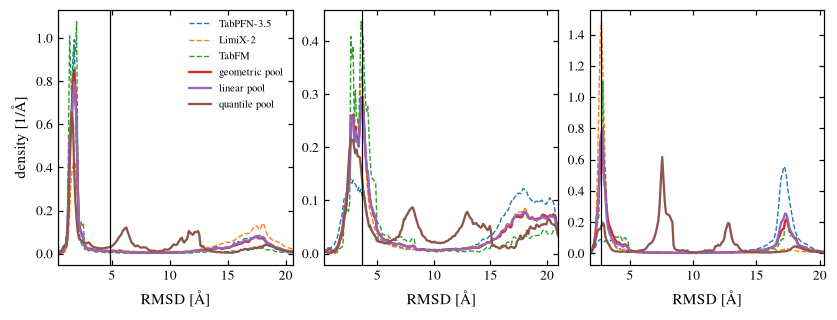

In [7]:
singles = ["TabPFN-3.5", "LimiX-2", "TabFM"]
medians = np.stack([predicted[label].median() for label in singles])
rows = np.argsort(np.ptp(medians, axis=0))[-3:]  # Most disagreement
display = lazy.Grid.linear(0.0, 21.0, 210)  # 0.1 Å bins, for the eye

fig, axes = plt.subplots(1, 3, figsize=(7.5, 2.8), layout="constrained")
for ax, row in zip(axes, rows, strict=True):
    for i, label in enumerate(MODELS):
        pooled = label.endswith("pool")
        ax.plot(
            display.centers,
            predicted[label][row].on_grid(display)[0],
            color=f"C{i}",
            lw=1.5 if pooled else 0.9,
            ls="-" if pooled else "--",
            label=label,
        )
    ax.axvline(y_test[row], color="k", lw=0.8)
    low, high = predicted["linear pool"][row].ppf([0.005, 0.995])[0]
    ax.set_xlim(low, high)
    ax.set_xlabel("RMSD [Å]")
axes[0].set_ylabel("density [1/Å]")
axes[0].legend(fontsize="x-small")
plt.show()

The figure shows the densities that each model and each pool predicts for
the three test rows on which the medians of the three models differ the
most, with the true RMSD marked by the vertical line. All of them have a
narrow peak at low RMSD and a broad tail or second peak at high RMSD, and
the models differ mostly in how much probability they give to the latter
(e.g., TabPFN-3.5 puts a second peak near 17 Å in the right panel, which
the other two models do not). The geometric and the linear pools lie
between the members and keep the shared low-RMSD peak, while the second
peak of TabPFN-3.5 is reduced to about half its height. In contrast, the
quantile pool puts peaks where none of the members has one (e.g., near
7.5 Å and 12.7 Å in the right panel), since averaging the quantiles of
densities that put their peaks in different places moves probability into
the gaps between them. This is why we recommend the quantile pool only for
members that agree on the shape of the distribution, and it explains its
poor CDE loss in the table above.

## Inside a pool

A fitted pool keeps its members by name in `named_estimators_` (and in
order in `estimators_`), their weights in `weights_`, and the grid on which
it pooled them in `native_grid_`, which is also its default output grid.
Here, the grid spans the range of the context targets, 0 to 21 Å, padded by
25% on each side, in 1,754 bins of about the width of TabPFN-3.5's own
buckets. The parameters of each member are reachable through `get_params`
and `set_params` as `<member>__<parameter>`, so `clone` and scikit-learn's
search objects can tune them, e.g., `GridSearchCV(pool,
{"tabfm__n_estimators": [4, 8]})`.

In [8]:
print(pool.name_)
print(list(pool.named_estimators_), pool.weights_)
print(pool.native_grid_)
print(pool.get_params()["tabfm__n_estimators"])

geometric(tabpfn:v3.5, limix:v2, tabfm:v1.0)
['tabpfn', 'limix', 'tabfm'] [0.33333333 0.33333333 0.33333333]
Grid(n_bins=1754, y_min=-5.2495, y_max=26.2475, normalization='histogram')
4


The pool also records each member's provenance in `provenance_`, together
with the pooling and the grid (see
[Reproducibility and provenance](https://lazy-tfm.readthedocs.io/en/latest/guide/reproducibility.html)).
For fewer than 3,000 context rows, a pool of two or more members warns,
since our tests found that an equal pool can then be dragged down by its
weakest member.

For the next steps, we suggest the following pages:

- [Ensembles of models](https://lazy-tfm.readthedocs.io/en/latest/guide/ensembles.html):
  the pools, our own tests of them, and their cost.
- [Choosing a model](https://lazy-tfm.readthedocs.io/en/latest/guide/choosing.html):
  which single model to choose, and what hardware it needs.
- [Scaling and performance](https://lazy-tfm.readthedocs.io/en/latest/guide/scaling.html):
  the measured cost of each model on larger contexts.